In [74]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [67]:
import csv
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import seaborn as sns
from joblib import load
from PIL import Image
import json, pickle
import gc
from joblib import Parallel, delayed
from copy import deepcopy
from rdkit.Chem.Draw import MolsToGridImage
import math


sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *
from macaw.generators import library_evolver

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600
from matplotlib.ticker import AutoMinorLocator
from scipy.stats import gaussian_kde


from copy import deepcopy
from joblib import Parallel, delayed
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%run "./plotting.py"

1.0.1


In [68]:
from art.core import RecommendationEngine
import art.utility as utils
from art.plot import predictions_vs_observations, predictions_distr_vs_observations
import pickle
import cloudpickle

In [69]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
HuggingFaceModelsDir = os.path.join(dataDir, 'HuggingFace_models/')
DORANETmoleculesDataDir = '/users/sghosh6/DTRA_project/MACAW/doranet/scripts'
resultsDir = os.path.join(dataDir, 'Results/combinedEbolaVirus_bestMACAW_allDB_generative/')
os.makedirs(resultsDir, exist_ok=True)

### Load saved `MACAW` transformer

In [70]:
macaw_load_path = os.path.join(resultsDir, "combinedEbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirusData_allDB_MACAW_transformer.joblib


### Load pre-trained `ART` model

ART model loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/ART_MACAW/ART_results/art.cpkl
ART output directory: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative


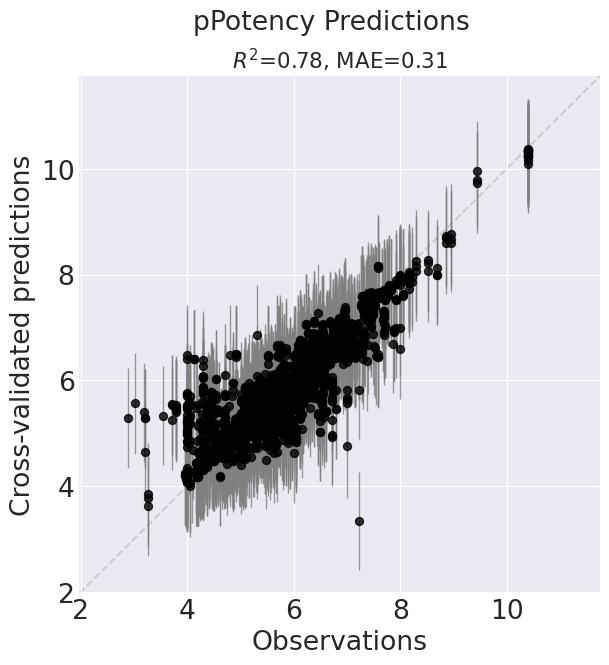

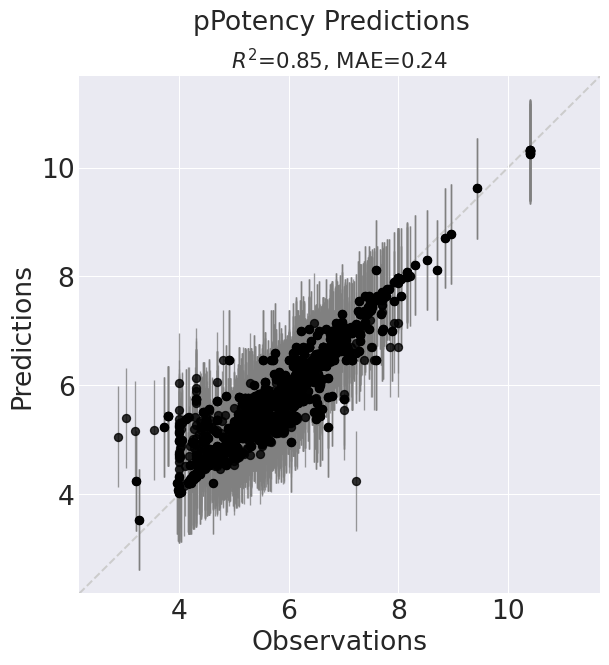

In [71]:
ARTtrainedModelFile = os.path.join(resultsDir, "ART_MACAW/ART_results/art.cpkl")
with open(ARTtrainedModelFile, "rb") as f:
    art_macaw = cloudpickle.load(f)

print(f"ART model loaded from: {ARTtrainedModelFile}")

# Force ART to use the current result directory
art_macaw.output_dir = resultsDir
os.makedirs(art_macaw.output_dir, exist_ok=True)

print(f"ART output directory: {art_macaw.output_dir}")

# Generate both ART plots
predictions_vs_observations(art_macaw,cv=True,error_bars=True)

predictions_vs_observations(art_macaw,cv=False,error_bars=True)

## Load compounds with `predicted` and `experimental` potency

### `DORAnet` generated molecules with starter: `Inosine + Adenosine + Guanosine + Xanthosine`

In [72]:
combinedEbola_allDORAnetGenerated_Antivirals_wART = pd.read_csv(resultsDir + "/combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.csv")
combinedEbola_allDORAnetGenerated_Antivirals_wART = combinedEbola_allDORAnetGenerated_Antivirals_wART[['Canonical_SMILES', 'source_DataBase','pPotency_prediction','pPotency_std']]
combinedEbola_allDORAnetGenerated_Antivirals_wART

,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,InosineOnly_gen3,6.156156,0.476241
1,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,InosineOnly_gen3,5.989034,0.473052
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,InosineOnly_gen3,5.906960,0.473610
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,InosineOnly_gen3,5.825261,0.472941
4,CC(=O)OP(=O)(O)OC(C)=O,AdenosineOnly_gen3,5.757650,0.479591
...,...,...,...,...
20367,CC(O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@]1(C#N)n1cn...,AdenosineOnly_gen3,5.036312,0.479170
20368,N#C[C@]1(n2cnc3c(=O)[nH]c(N)nc32)O[C@H](CO)[C@...,GuanosineOnly_gen3,4.995117,0.477091
20369,N#C[C@]1(n2cnc3c(=O)[nH]cnc32)O[C@H](CO)[C@@H]...,InosineOnly_gen3,4.944989,0.477190
20370,N#C[C@]1(n2cnc3c(N)ncnc32)O[C@H](C(O)O)[C@@H](...,AdenosineOnly_gen3,4.925072,0.478121


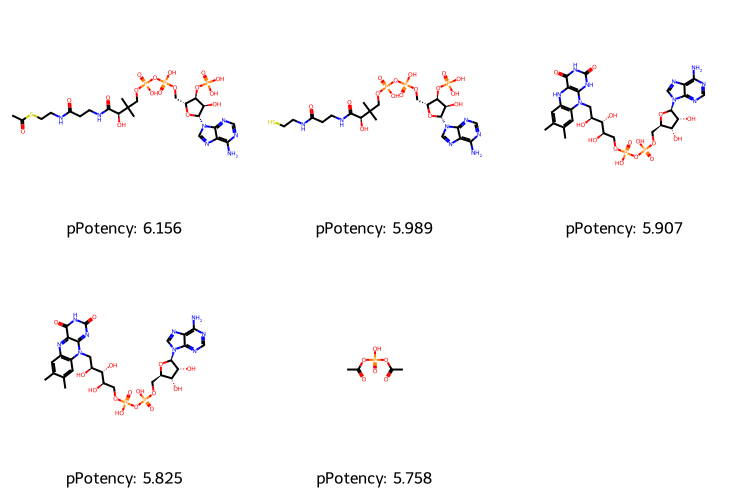

In [79]:
from rdkit.Chem.Draw import MolsToGridImage
import math

df = combinedEbola_allDORAnetGenerated_Antivirals_wART.head(5).copy()

mols = []
legends = []

for _, row in df.iterrows():
    smi = row["Canonical_SMILES"]
    p = row["pPotency_prediction"]

    mol = Chem.MolFromSmiles(smi) if isinstance(smi, str) else None
    if mol is None:
        continue

    mols.append(mol)
    try:
        legends.append(f"pPotency: {float(p):.3f}")  # 3 decimal places
    except Exception:
        legends.append(f"pPotency: {p}")

# Arrange to display in two rows
n = len(mols)
molsPerRow = math.ceil(n / 2)  # for 5 items -> 3 on first row, 2 on second

img = MolsToGridImage(
    mols,
    legends=legends,
    molsPerRow=molsPerRow,
    subImgSize=(250, 250),
)

img  

### Use MACAW's `library_evolver` to generate new molecules

see this directory:
`/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/MACAW_InverseDesign/InoAdeGuoXan/run0`

In [80]:
combinedEbola_MACAWGenerated_Antivirals_run0 = pd.read_csv(resultsDir + "/MACAW_InverseDesign/InoAdeGuoXan/run0/MACAW_inverseDesign_results/MACAW_generatedCompound_multiCampaign_top500.csv")
combinedEbola_MACAWGenerated_Antivirals_run0

,Canonical_SMILES,pPotency_prediction,target_pPotency,targetError,campaignLabel,campaignBase,randomSeed,algorithm,p,k1,k2,n_rounds,n_hits,noise_factor_schedule,targetMatchRank,within_0p1,within_0p25,within_0p5
0,COOC(=CCCNNPC=C1N2C3CCC(C)C=CP=NPCC(O)PNSNC(NC...,6.334291,6.5,0.165709,position_exp_broad_seed62,position_exp_broad,62,position,exp,15000,400,6,150,"[0.7, 0.55, 0.4, 0.28, 0.18, 0.1]",1,False,True,True
1,CC#[PH]CNNNSNCC1C=[PH](CC#C[SH]=NNN(C)C)NCON2C...,6.331470,6.5,0.168530,position_exp_broad_seed72,position_exp_broad,72,position,exp,15000,400,6,150,"[0.7, 0.55, 0.4, 0.28, 0.18, 0.1]",2,False,True,True
2,CC1CCCOSOOP=CP[SH]=CCSOC2NCC3P=CPN=[SH]P=[SH]C...,6.327486,6.5,0.172514,position_exp_broad_seed72,position_exp_broad,72,position,exp,15000,400,6,150,"[0.7, 0.55, 0.4, 0.28, 0.18, 0.1]",3,False,True,True
3,C=NOPCC#COC1(C=O)C#[PH]SN=CCSOOC2C(S)CC[SH]=CC...,6.301410,6.5,0.198590,position_exp_broad_seed72,position_exp_broad,72,position,exp,15000,400,6,150,"[0.7, 0.55, 0.4, 0.28, 0.18, 0.1]",4,False,True,True
4,CC[SH]=[PH]=[PH]=[SH]N1CCCN=C=C=[SH]CN[SH]2S#[...,6.289257,6.5,0.210743,position_exp_broad_seed72,position_exp_broad,72,position,exp,15000,400,6,150,"[0.7, 0.55, 0.4, 0.28, 0.18, 0.1]",5,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,CNP(N)C1(C)COSONOS[SH](C2=P[SH]=PC=CCC[SH]=CSC...,6.080187,6.5,0.419813,position_exp_broad_seed62,position_exp_broad,62,position,exp,15000,400,6,150,"[0.7, 0.55, 0.4, 0.28, 0.18, 0.1]",296,False,False,True
296,C=[PH]1POC#[PH]P2#[PH]CCNONCN3C(N=NOOSP(N)#[PH...,6.080063,6.5,0.419937,position_exp_broad_seed62,position_exp_broad,62,position,exp,15000,400,6,150,"[0.7, 0.55, 0.4, 0.28, 0.18, 0.1]",297,False,False,True
297,O=CNSC[SH]1(=NCCSP=S)OPOSOCNNP2CN2NCCC#CPOCC=C...,6.079532,6.5,0.420468,position_exp_broad_seed62,position_exp_broad,62,position,exp,15000,400,6,150,"[0.7, 0.55, 0.4, 0.28, 0.18, 0.1]",298,False,False,True
298,CN(S)N1C=CC[SH]2C=[SH]P[PH]34ONCC=PC56CC=N[SH]...,6.078696,6.5,0.421304,position_exp_broad_seed62,position_exp_broad,62,position,exp,15000,400,6,150,"[0.7, 0.55, 0.4, 0.28, 0.18, 0.1]",299,False,False,True


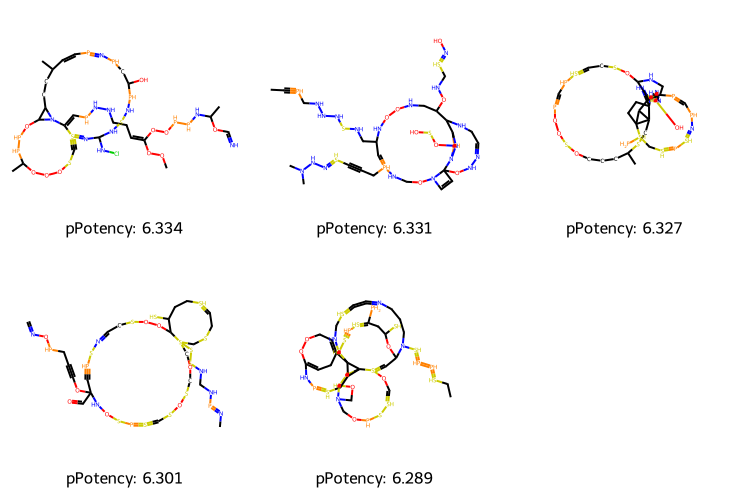

In [81]:
df = combinedEbola_MACAWGenerated_Antivirals_run0.head(5).copy()

mols = []
legends = []

for _, row in df.iterrows():
    smi = row["Canonical_SMILES"]
    p = row["pPotency_prediction"]

    mol = Chem.MolFromSmiles(smi) if isinstance(smi, str) else None
    if mol is None:
        continue

    mols.append(mol)
    try:
        legends.append(f"pPotency: {float(p):.3f}")  # 3 decimal places
    except Exception:
        legends.append(f"pPotency: {p}")

# Arrange to display in two rows
n = len(mols)
molsPerRow = math.ceil(n / 2)  # for 5 items -> 3 on first row, 2 on second

img = MolsToGridImage(
    mols,
    legends=legends,
    molsPerRow=molsPerRow,
    subImgSize=(250, 250),
)

img  

# `DORAnet` generated molecules with starter: `Remdesivir`

In [ ]:
RemdesivirOnly_DORAnetGenerated_wART = pd.read_csv(resultsDir + "/RemdesivirOnly_DORAnetGenerated_ARTprediction.csv")
RemdesivirOnly_DORAnetGenerated_wART = RemdesivirOnly_DORAnetGenerated_wART[['Canonical_SMILES', 'source_DataBase','pPotency_prediction','pPotency_std']]
RemdesivirOnly_DORAnetGenerated_wART

### Use MACAW's `library_evolver` to generate new molecules

In [ ]:
# -----------------------------
# job settings
# -----------------------------
seedDF = RemdesivirOnly_DORAnetGenerated_wART.copy()
targetPotency = 7.0
smilesCol = "Canonical_SMILES"
potencyCol = "pPotency_prediction"
stdCol = "pPotency_std"
sourceCol = "source_DataBase"

nTargetClosestSeeds = 300
randomSeeds = [42, 52, 62, 72, 82]
outputPrefix = "MACAW_generatedCompound"
outputDir = globals().get("resultsDir", ".")
saveOutputs = True

campaignConfigs = [
    ("transition_empirical_refine", "transition", "empirical", 8000, 200, 5, 100, [0.30, 0.22, 0.16, 0.10, 0.08]),
    ("transition_cumsum_broad", "transition", "cumsum", 15000, 400, 6, 150, [0.65, 0.50, 0.35, 0.25, 0.16, 0.10]),
    ("position_exp_broad", "position", "exp", 15000, 400, 6, 150, [0.70, 0.55, 0.40, 0.28, 0.18, 0.10]),
    ("dual_cumsum_broad", "dual", "cumsum", 12000, 300, 6, 150, [0.60, 0.45, 0.32, 0.22, 0.15, 0.10]),
]


# -----------------------------
# Helpers
# -----------------------------
def canonicalizeSmiles(smiles):
    """Return canonical SMILES or None if invalid."""
    if pd.isna(smiles):
        return None
    mol = Chem.MolFromSmiles(str(smiles).strip())
    return Chem.MolToSmiles(mol, canonical=True) if mol is not None else None


def artMeanModelForLibraryEvolver(X):
    """Convert MACAW embeddings to ART mean pPotency predictions."""
    macawFeatureDF = pd.DataFrame(X, columns=[f"MACAW_{i}" for i in range(X.shape[1])])
    pred = art_macaw.predict(macawFeatureDF)

    if isinstance(pred, pd.DataFrame):
        for col in ["pPotency_prediction", "prediction", "mean"]:
            if col in pred.columns:
                return pred[col].to_numpy()

    if isinstance(pred, dict):
        for key in ["pPotency_prediction", "prediction", "mean", "y_mean"]:
            if key in pred:
                return np.asarray(pred[key]).ravel()

    if isinstance(pred, (tuple, list)):
        return np.asarray(pred[0]).ravel()

    return np.asarray(pred).ravel()


def selectTargetClosestSeeds(inputDF):
    """Select starter compounds closest to targetPotency."""
    DF = inputDF.copy()

    DF[smilesCol] = DF[smilesCol].apply(canonicalizeSmiles)
    DF[potencyCol] = pd.to_numeric(DF[potencyCol], errors="coerce")

    if stdCol in DF.columns:
        DF[stdCol] = pd.to_numeric(DF[stdCol], errors="coerce")

    DF = DF.dropna(subset=[smilesCol, potencyCol]).copy()
    DF["seedTargetError"] = (DF[potencyCol] - targetPotency).abs()

    DF = (
        DF.sort_values("seedTargetError", ascending=True)
        .drop_duplicates(subset=[smilesCol], keep="first")
        .nsmallest(nTargetClosestSeeds, "seedTargetError")
        .reset_index(drop=True)
    )

    DF["seedSelectionScore"] = DF["seedTargetError"]
    DF["seedRank"] = np.arange(1, len(DF) + 1)

    displayCols = [
        col for col in [
            "seedRank", smilesCol, sourceCol, potencyCol, stdCol,
            "seedTargetError", "seedSelectionScore"
        ]
        if col in DF.columns
    ]

    return DF, DF[smilesCol].tolist(), DF[displayCols].copy()


def runOneCampaign(seedSmiles, cfg, randomSeed):
    """Run one MACAW library_evolver campaign."""
    label, algorithm, pMode, k1, k2, nRounds, nHits, noiseSchedule = cfg
    campaignLabel = f"{label}_seed{randomSeed}"

    print(f"\nRunning {campaignLabel}")

    result = library_evolver(
        smiles=seedSmiles,
        model=artMeanModelForLibraryEvolver,
        mcw=mcw,
        spec=targetPotency,
        k1=k1,
        k2=k2,
        n_rounds=nRounds,
        n_hits=nHits,
        noise_factor=noiseSchedule,
        algorithm=algorithm,
        p=pMode,
        force_new=True,
        random_state=randomSeed,
    )

    if isinstance(result, tuple) and len(result) >= 2:
        smilesOut, predOut = result[0], result[1]
    else:
        smilesOut = result
        predOut = artMeanModelForLibraryEvolver(mcw.transform(smilesOut))

    DF = pd.DataFrame({
        smilesCol: smilesOut,
        potencyCol: np.asarray(predOut).ravel(),
        "target_pPotency": targetPotency,
        "targetError": np.abs(np.asarray(predOut).ravel() - targetPotency),
        "campaignLabel": campaignLabel,
        "campaignBase": label,
        "randomSeed": randomSeed,
        "algorithm": algorithm,
        "p": pMode,
        "k1": k1,
        "k2": k2,
        "n_rounds": nRounds,
    })

    DF[smilesCol] = DF[smilesCol].apply(canonicalizeSmiles)
    DF = DF.dropna(subset=[smilesCol]).reset_index(drop=True)

    print(f"Finished {campaignLabel}: {len(DF)} molecules, best targetError = {DF['targetError'].min():.4f}")
    return DF


def summarizeResults(allResults):
    """Merge, deduplicate, rank, and summarize generated molecules."""
    if not allResults:
        return pd.DataFrame(), pd.DataFrame()

    DF = (
        pd.concat(allResults, ignore_index=True)
        .sort_values("targetError", ascending=True)
        .drop_duplicates(subset=[smilesCol], keep="first")
        .reset_index(drop=True)
    )

    DF["targetMatchRank"] = np.arange(1, len(DF) + 1)

    for tol in [0.10, 0.25, 0.50]:
        DF[f"within_{str(tol).replace('.', 'p')}"] = DF["targetError"] <= tol

    summaryDF = (
        DF.groupby("campaignBase")
        .agg(
            nUniqueReturned=(smilesCol, "count"),
            bestTargetError=("targetError", "min"),
            medianTargetError=("targetError", "median"),
            nWithin0p25=("within_0p25", "sum"),
            nWithin0p50=("within_0p50", "sum"),
        )
        .reset_index()
        .sort_values(["bestTargetError", "nWithin0p25"], ascending=[True, False])
    )

    return DF, summaryDF


def saveOutputFiles(saveMap, failedCampaignDF=None):
    """Save output DataFrames to CSV."""
    os.makedirs(outputDir, exist_ok=True)

    for suffix, DF in saveMap.items():
        DF.to_csv(os.path.join(outputDir, f"{outputPrefix}_{suffix}.csv"), index=False)

    if failedCampaignDF is not None and len(failedCampaignDF) > 0:
        failedCampaignDF.to_csv(os.path.join(outputDir, f"{outputPrefix}_failed_campaigns.csv"), index=False)


# -----------------------------
# Run workflow
# -----------------------------
seedDF, seedSmiles, starterSeedPotencyDF = selectTargetClosestSeeds(seedDF)

print(f"targetPotency used now: {targetPotency}")
print(f"Number of selected starter seed molecules: {len(seedSmiles)}")
print(f"Starter seed pPotency range: {seedDF[potencyCol].min():.6f} to {seedDF[potencyCol].max():.6f}")
print(f"Starter seed targetError range: {seedDF['seedTargetError'].min():.6f} to {seedDF['seedTargetError'].max():.6f}")

#display(starterSeedPotencyDF.head(nTargetClosestSeeds))

allResults, failedCampaigns = [], []

for cfg in campaignConfigs:
    for randomSeed in randomSeeds:
        try:
            allResults.append(runOneCampaign(seedSmiles, cfg, randomSeed))
        except Exception as exc:
            failedCampaigns.append({
                "campaignLabel": f"{cfg[0]}_seed{randomSeed}",
                "errorMessage": str(exc),
            })
            print(f"FAILED {cfg[0]}_seed{randomSeed}: {exc}")

expandedTargetMatchedDF, campaignSummaryDF = summarizeResults(allResults)
failedCampaignDF = pd.DataFrame(failedCampaigns)

print("\nMULTI-CAMPAIGN SEARCH COMPLETE")
print(f"Total unique generated molecules: {len(expandedTargetMatchedDF)}")

if len(expandedTargetMatchedDF) > 0:
    print(f"Molecules within ±0.25 pPotency: {expandedTargetMatchedDF['within_0p25'].sum()}")

print("\nCampaign summary:")
campaignSummaryDF
'''
if saveOutputs and len(expandedTargetMatchedDF) > 0:
    saveOutputFiles({
        "targetClosest_seed_molecules": seedDF,
        "starter_seed_pPotency_values": starterSeedPotencyDF,
        "multiCampaign_all_results": expandedTargetMatchedDF,
        "multiCampaign_summary": campaignSummaryDF,
        "multiCampaign_top500": expandedTargetMatchedDF.head(500),
        "multiCampaign_within_0p25": expandedTargetMatchedDF[expandedTargetMatchedDF["within_0p25"]],
    }, failedCampaignDF)

    print("\nSaved output files to:", outputDir)
'''

### Combine the data frames

In [ ]:
# List the dataframes in the order you want them joined
dFs_to_combine = [
    combinedEbola_allDORAnetGenerated_Antivirals_wART, 
    RemdesivirOnly_DORAnetGenerated_wART, 
]

# Concatenate vertically
starterCandidates_4MACAW_generation = pd.concat(dFs_to_combine, axis=0, ignore_index=True)
starterCandidates_4MACAW_generation

## Use MACAW's `library_evolver` to generate new molecules

In [ ]:
# ============================================================
# Concise MACAW + ART multi-campaign generation
# Seeds: highest pPotency_prediction compounds
# Goal: generated molecules close to targetPotency
# ============================================================


# -----------------------------
# User settings
# -----------------------------
targetPotency = 7.0
smilesCol = "Canonical_SMILES"
potencyCol = "pPotency_prediction"
stdCol = "pPotency_std"
sourceCol = "source_DataBase"

nTargetClosestSeeds = 300
randomSeeds = [42, 52, 62, 72, 82]
outputPrefix = "MACAW_generatedCompound"
saveOutputs = True


# -----------------------------
# Helper: canonicalize SMILES
# -----------------------------
def canonicalizeSmiles(smiles):
    """Return canonical SMILES or None if invalid."""
    if pd.isna(smiles):
        return None

    mol = Chem.MolFromSmiles(str(smiles).strip())
    return Chem.MolToSmiles(mol, canonical=True) if mol is not None else None


# -----------------------------
# Helper: ART mean prediction wrapper for library_evolver
# -----------------------------
def artMeanModelForLibraryEvolver(X):
    """
    MACAW library_evolver passes MACAW embeddings X into this function.
    This wrapper converts X into MACAW_ feature columns and returns only
    ART mean pPotency predictions.
    """
    macawFeatureDF = pd.DataFrame(
        X,
        columns=[f"MACAW_{i}" for i in range(X.shape[1])]
    )

    pred = art_macaw.predict(macawFeatureDF)

    if isinstance(pred, pd.DataFrame):
        for col in ["pPotency_prediction", "prediction", "mean"]:
            if col in pred.columns:
                return pred[col].to_numpy()

    if isinstance(pred, dict):
        for key in ["pPotency_prediction", "prediction", "mean", "y_mean"]:
            if key in pred:
                return np.asarray(pred[key]).ravel()

    if isinstance(pred, (tuple, list)):
        return np.asarray(pred[0]).ravel()

    return np.asarray(pred).ravel()


# -----------------------------
# Step 1: choose starting seeds closest to targetPotency
# -----------------------------
seedDF = starterCandidates_4MACAW_generation.copy()

# Clean and canonicalize SMILES
seedDF[smilesCol] = seedDF[smilesCol].apply(canonicalizeSmiles)

# Convert potency to numeric safely
seedDF[potencyCol] = pd.to_numeric(seedDF[potencyCol], errors="coerce")

# Keep valid rows only
seedDF = seedDF.dropna(subset=[smilesCol, potencyCol]).copy()

# Important: sort BEFORE dedup so the best row is kept for duplicate SMILES
seedDF["seedTargetError"] = (seedDF[potencyCol] - targetPotency).abs()

seedDF = (
    seedDF
    .sort_values("seedTargetError", ascending=True)
    .drop_duplicates(subset=[smilesCol], keep="first")
    .reset_index(drop=True)
)

# Select molecules closest to targetPotency
seedDF = seedDF.nsmallest(nTargetClosestSeeds, "seedTargetError").reset_index(drop=True)

seedDF["seedSelectionScore"] = seedDF["seedTargetError"]
seedDF["seedRank"] = np.arange(1, len(seedDF) + 1)

seedSmiles = seedDF[smilesCol].tolist()

print(f"targetPotency used now: {targetPotency}")
print(f"Number of cleaned seed molecules: {len(seedSmiles)}")

display(
    seedDF[
        [
            "seedRank",
            smilesCol,
            sourceCol,
            potencyCol,
            stdCol,
            "seedTargetError",
            "seedSelectionScore",
        ]
    ].head(20)
)

# -----------------------------
# Step 2: define compact multi-campaign settings
# -----------------------------
campaignConfigs = [
    {
        "campaignLabel": "transition_empirical_refine",
        "algorithm": "transition",
        "p": "empirical",
        "k1": 8000,
        "k2": 200,
        "n_rounds": 5,
        "n_hits": 100,
        "noise_factor": [0.30, 0.22, 0.16, 0.10, 0.08],
    },
    {
        "campaignLabel": "transition_cumsum_broad",
        "algorithm": "transition",
        "p": "cumsum",
        "k1": 15000,
        "k2": 400,
        "n_rounds": 6,
        "n_hits": 150,
        "noise_factor": [0.65, 0.50, 0.35, 0.25, 0.16, 0.10],
    },
    {
        "campaignLabel": "position_exp_broad",
        "algorithm": "position",
        "p": "exp",
        "k1": 15000,
        "k2": 400,
        "n_rounds": 6,
        "n_hits": 150,
        "noise_factor": [0.70, 0.55, 0.40, 0.28, 0.18, 0.10],
    },
    {
        "campaignLabel": "dual_cumsum_broad",
        "algorithm": "dual",
        "p": "cumsum",
        "k1": 12000,
        "k2": 300,
        "n_rounds": 6,
        "n_hits": 150,
        "noise_factor": [0.60, 0.45, 0.32, 0.22, 0.15, 0.10],
    },
]


# -----------------------------
# Step 3: run multi-campaign library_evolver
# -----------------------------
allResults = []
failedCampaigns = []

for cfg in campaignConfigs:
    for seed in randomSeeds:
        campaignLabel = f"{cfg['campaignLabel']}_seed{seed}"
        print(f"\nRunning {campaignLabel}")

        try:
            result = library_evolver(
                smiles=seedSmiles,
                model=artMeanModelForLibraryEvolver,
                mcw=mcw,
                spec=targetPotency,
                k1=cfg["k1"],
                k2=cfg["k2"],
                n_rounds=cfg["n_rounds"],
                n_hits=cfg["n_hits"],
                noise_factor=cfg["noise_factor"],
                algorithm=cfg["algorithm"],
                p=cfg["p"],
                force_new=True,
                random_state=seed,
            )

            # Handle MACAW versions returning either SMILES only or (SMILES, predictions)
            if isinstance(result, tuple) and len(result) >= 2:
                smilesOut, predOut = result[0], result[1]
            else:
                smilesOut = result
                predOut = artMeanModelForLibraryEvolver(mcw.transform(smilesOut))

            campaignDF = pd.DataFrame({
                smilesCol: smilesOut,
                potencyCol: np.asarray(predOut).ravel(),
                "target_pPotency": targetPotency,
                "campaignLabel": campaignLabel,
                "campaignBase": cfg["campaignLabel"],
                "randomSeed": seed,
                "algorithm": cfg["algorithm"],
                "p": cfg["p"],
                "k1": cfg["k1"],
                "k2": cfg["k2"],
                "n_rounds": cfg["n_rounds"],
            })

            campaignDF[smilesCol] = campaignDF[smilesCol].apply(canonicalizeSmiles)
            campaignDF = campaignDF.dropna(subset=[smilesCol])
            campaignDF["targetError"] = (campaignDF[potencyCol] - targetPotency).abs()

            allResults.append(campaignDF)

            print(
                f"Finished {campaignLabel}: "
                f"{len(campaignDF)} molecules, "
                f"best targetError = {campaignDF['targetError'].min():.4f}"
            )

        except Exception as exc:
            failedCampaigns.append({
                "campaignLabel": campaignLabel,
                "errorMessage": str(exc),
            })
            print(f"FAILED {campaignLabel}: {exc}")


# -----------------------------
# Step 4: merge, deduplicate, rank, summarize, save
# -----------------------------
if len(allResults) == 0:
    expandedTargetMatchedDF = pd.DataFrame()
    campaignSummaryDF = pd.DataFrame()
    failedCampaignDF = pd.DataFrame(failedCampaigns)
    print("\nNo successful campaigns.")
else:
    expandedTargetMatchedDF = pd.concat(allResults, ignore_index=True)

    # Deduplicate and keep molecule closest to targetPotency
    expandedTargetMatchedDF = (
        expandedTargetMatchedDF
        .sort_values("targetError", ascending=True)
        .drop_duplicates(subset=[smilesCol], keep="first")
        .reset_index(drop=True)
    )

    expandedTargetMatchedDF["targetMatchRank"] = np.arange(
        1, len(expandedTargetMatchedDF) + 1
    )

    expandedTargetMatchedDF["within_0p10"] = expandedTargetMatchedDF["targetError"] <= 0.10
    expandedTargetMatchedDF["within_0p25"] = expandedTargetMatchedDF["targetError"] <= 0.25
    expandedTargetMatchedDF["within_0p50"] = expandedTargetMatchedDF["targetError"] <= 0.50

    campaignSummaryDF = (
        expandedTargetMatchedDF
        .groupby("campaignBase")
        .agg(
            nUniqueReturned=(smilesCol, "count"),
            bestTargetError=("targetError", "min"),
            medianTargetError=("targetError", "median"),
            nWithin0p25=("within_0p25", "sum"),
            nWithin0p50=("within_0p50", "sum"),
        )
        .reset_index()
        .sort_values(["bestTargetError", "nWithin0p25"], ascending=[True, False])
    )

    failedCampaignDF = pd.DataFrame(failedCampaigns)

    print("\nMULTI-CAMPAIGN SEARCH COMPLETE")
    print(f"Total unique generated molecules: {len(expandedTargetMatchedDF)}")
    print(f"Molecules within ±0.25 pPotency: {expandedTargetMatchedDF['within_0p25'].sum()}")

    display(
        expandedTargetMatchedDF[
            [
                "targetMatchRank",
                smilesCol,
                potencyCol,
                "target_pPotency",
                "targetError",
                "campaignLabel",
                "algorithm",
                "p",
            ]
        ].head(50)
    )

    display(campaignSummaryDF)

    if saveOutputs:
        seedDF.to_csv(resultsDir + f"{outputPrefix}_highestPotency_seed_molecules.csv", index=False)
        expandedTargetMatchedDF.to_csv(resultsDir + f"{outputPrefix}_multiCampaign_all_results.csv", index=False)
        campaignSummaryDF.to_csv(resultsDir + f"{outputPrefix}_multiCampaign_summary.csv", index=False)
        expandedTargetMatchedDF.head(500).to_csv(resultsDir + f"{outputPrefix}_multiCampaign_top500.csv", index=False)
        expandedTargetMatchedDF[expandedTargetMatchedDF["within_0p25"]].to_csv(resultsDir + f"{outputPrefix}_multiCampaign_within_0p25.csv",index=False,)

        if len(failedCampaignDF) > 0:
            failedCampaignDF.to_csv(f"{outputPrefix}_failed_campaigns.csv", index=False)

        print("\nSaved outputs:")
        print(f"  {outputPrefix}_highestPotency_seed_molecules.csv")
        print(f"  {outputPrefix}_multiCampaign_all_results.csv")
        print(f"  {outputPrefix}_multiCampaign_summary.csv")
        print(f"  {outputPrefix}_multiCampaign_top500.csv")
        print(f"  {outputPrefix}_multiCampaign_within_0p25.csv")